# EM-DAT flood impacts, and where they happened

EM-DAT records *what a disaster cost* — deaths, people affected, damage in dollars. It does not record *where*
the disaster was, beyond a country and a single coordinate pair. GDIS fills that gap: it geocodes EM-DAT's
natural disasters onto administrative units.

This notebook fetches both for Bangladesh floods and joins them, so each impact figure lands on a map.

Two things worth knowing before you run it:

* **`emdat:events` needs no credentials.** It comes from the EM-DAT Archive on the UCLouvain Dataverse.
* **`gdis:points` needs an [Earthdata Login](https://urs.earthdata.nasa.gov/users/new)**, plus a one-time
  acceptance of the SEDAC data-use agreement at
  [unaccepted_eulas](https://urs.earthdata.nasa.gov/users/earthaccess/unaccepted_eulas). Set
  `EARTHDATA_USERNAME` and `EARTHDATA_PASSWORD`, or put a `machine urs.earthdata.nasa.gov` line in `~/.netrc`.

The EM-DAT archive is CC-BY-NC-ND with a Terms of Use restricting *who* may use it for free — the download
raises a `LicenseWarning` saying so. See the
[introduction](../../reference/emdat/introduction.md) for the detail.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from earthlens.core import EarthLens

OUT = Path("_emdat_output")
OUT.mkdir(exist_ok=True)

BANGLADESH_LAT = [20.5, 26.7]
BANGLADESH_LON = [88.0, 92.7]

## 1. The impact record

One request, one `DataFrame`. `hazard=` and `country=` are matched case-insensitively, and only the *year* of
`start` / `end` matters — EM-DAT is indexed by event year.

In [2]:
events = EarthLens(
    "emdat",
    variables=["emdat:events"],
    start="1990-01-01",
    end="2018-12-31",
    hazard="flood",
    country="BGD",
    path=str(OUT),
).download()

print(f"{len(events)} flood events, {events['Start Year'].min()}-{events['Start Year'].max()}")
print("columns:", list(events.columns[:12]))

64 flood events, 1990-2018
columns: ['DisNo.', 'Historic', 'Classification Key', 'Disaster Group', 'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype', 'External IDs', 'Event Name', 'ISO', 'Country', 'Subregion']


The columns worth knowing: `Total Deaths` and `Total Affected` are the human impact, `Total Damage ('000 US$)`
is nominal and `Total Damage, Adjusted ('000 US$)` is CPI-adjusted — use the adjusted one to compare across
decades. Many cells are missing, which is normal for EM-DAT and is a property of the source, not the fetch.

## 2. Impact over time

Deaths and people affected move on completely different scales, so they need separate axes.

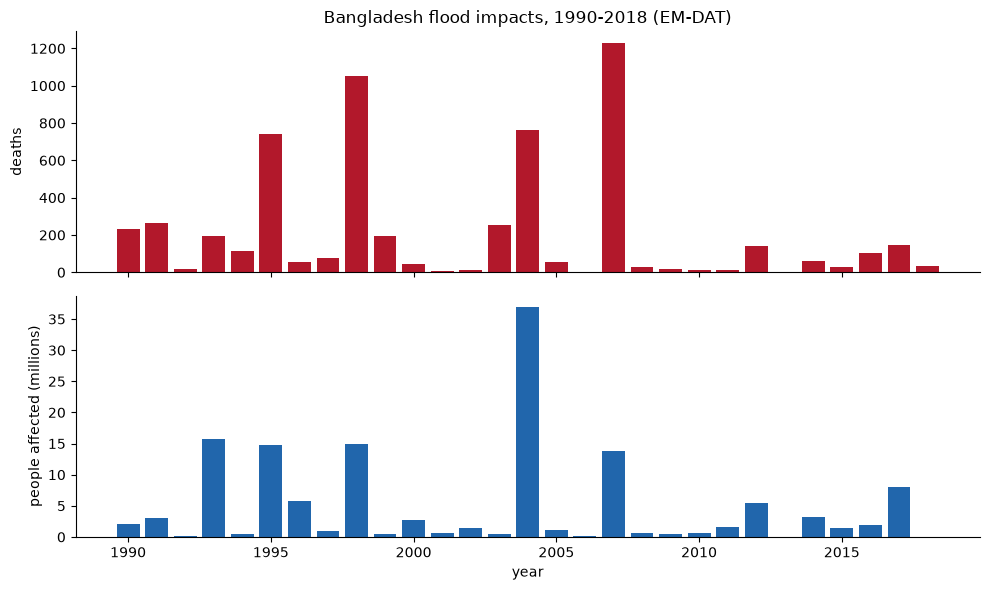

In [3]:
by_year = events.groupby("Start Year")[["Total Deaths", "Total Affected"]].sum()

fig, (ax_deaths, ax_affected) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax_deaths.bar(by_year.index, by_year["Total Deaths"], color="#b2182b")
ax_deaths.set_ylabel("deaths")
ax_deaths.set_title("Bangladesh flood impacts, 1990-2018 (EM-DAT)")
ax_affected.bar(by_year.index, by_year["Total Affected"] / 1e6, color="#2166ac")
ax_affected.set_ylabel("people affected (millions)")
ax_affected.set_xlabel("year")
for axis in (ax_deaths, ax_affected):
    axis.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

The 1998 and 2004 spikes are the well-known catastrophic monsoon floods. Note how deaths and people-affected
peak in different years — a flood can displace millions without a high death toll, and that distinction is
exactly what an impact database is for.

## 3. Where the events were

Now the geocoded side. `gdis:points` is the 1.09 MB centroid CSV — the same 39,953 locations as the 2.2 GB
polygon GeoPackage, and the only GDIS distribution carrying `year`, `latitude` and `longitude` outright.

GDIS is frozen at **1960-2018** and covers **natural hazards only**, which is why this notebook stops at 2018.

In [4]:
locations = EarthLens(
    "emdat",
    variables=["gdis:points"],
    start="1990-01-01",
    end="2018-12-31",
    hazard="flood",
    lat_lim=BANGLADESH_LAT,
    lon_lim=BANGLADESH_LON,
    path=str(OUT),
).download()

print(f"{len(locations)} geocoded flood locations, CRS {locations.crs}")
print("columns:", list(locations.columns))

442 geocoded flood locations, CRS EPSG:4326
columns: ['id', 'country', 'iso3', 'gwno', 'year', 'geo_id', 'geolocation', 'level', 'adm1', 'adm2', 'adm3', 'location', 'historical', 'hist_country', 'disastertype', 'disasterno', 'latitude', 'longitude', 'geometry']


One disaster covers many locations — GDIS has a row per affected administrative unit, so `disasterno` repeats.
That is what makes the join a one-to-many.

## 4. Joining impacts to places

EM-DAT's `DisNo.` is `2009-0631-BGD`; GDIS's `disasterno` is `2009-0631`. Drop the ISO3 suffix and they match.

In [5]:
events["disasterno"] = events["DisNo."].str.rsplit("-", n=1).str[0]
joined = locations.merge(
    events[["disasterno", "Total Deaths", "Total Affected"]], on="disasterno", how="inner"
)

print(f"{joined['disasterno'].nunique()} events matched, across {len(joined)} locations")
attributes = joined.columns.drop(joined.geometry.name)
print("joined columns:", list(attributes[:10]))

54 events matched, across 361 locations
joined columns: ['id', 'country', 'iso3', 'gwno', 'year', 'geo_id', 'geolocation', 'level', 'adm1', 'adm2']


## 5. The map

Each point is one affected administrative unit, sized by how many people that disaster affected nationally. The
size is an event-level figure repeated across its locations — it says "this location was part of a disaster that
affected N people", not "N people here".

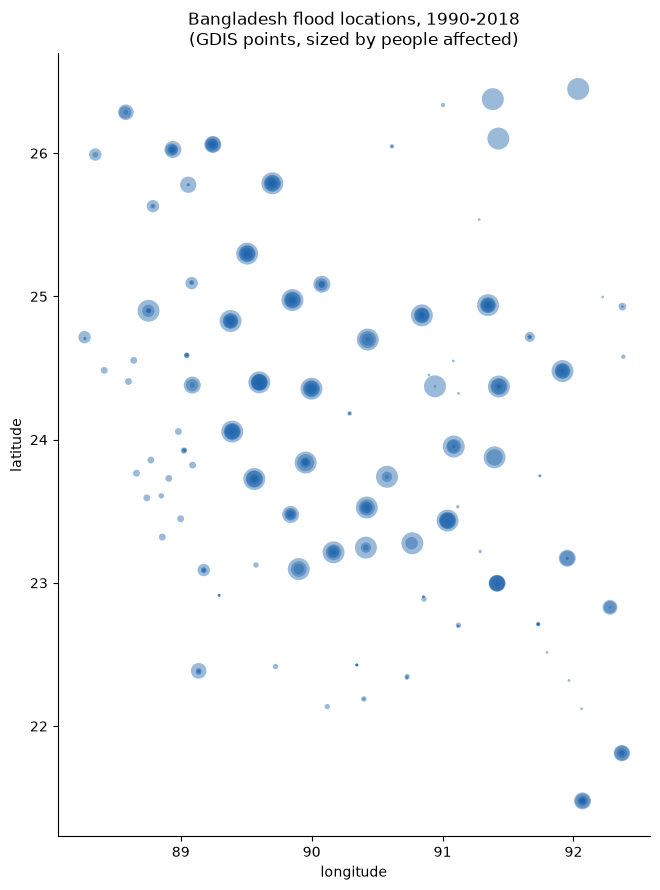

In [6]:
fig, ax = plt.subplots(figsize=(8, 9))
sizes = (joined["Total Affected"].fillna(0) / 1e5).clip(lower=4, upper=250)
joined.plot(ax=ax, markersize=sizes, alpha=0.45, color="#2166ac", edgecolor="none")
ax.set_title("Bangladesh flood locations, 1990-2018\n(GDIS points, sized by people affected)")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

## 6. Which districts flood most often

The geocoding is what makes this question answerable — the impact table alone only knows "Bangladesh".

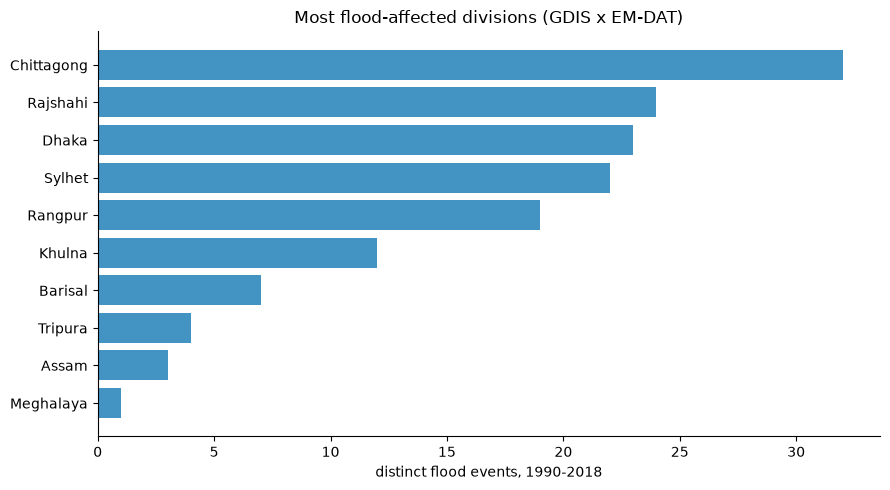

In [7]:
top = joined.groupby("adm1")["disasterno"].nunique().sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top.index[::-1], top.to_numpy()[::-1], color="#4393c3")
ax.set_xlabel("distinct flood events, 1990-2018")
ax.set_title("Most flood-affected divisions (GDIS x EM-DAT)")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

## Where to go next

* **Real footprints.** Swap `variables=["gdis:polygons"]` for admin-unit geometry instead of centroids — but
  it is a 2.2 GB download, so only when you need the shapes.
* **Other hazards.** `hazard=` takes any of `drought`, `earthquake`, `extreme temperature`, `flood`,
  `landslide`, `mass movement (dry)`, `storm`, `volcanic activity`, or a list of them.
* **Country summaries.** Yearly per-country aggregates are on HDX and need no new backend:
  `EarthLens("hdx", hdx_id="emdat-country-profiles", path="out").download()`.
* **Technological disasters.** `emdat:events` covers them too and runs from 1900 — drop `hazard=` and filter on
  `Disaster Group` instead. GDIS will not have them.

### Citation

* EM-DAT, CRED / UCLouvain, Brussels, Belgium — <https://www.emdat.be>. Archive DOI `10.14428/DVN/I0LTPH`.
* Rosvold, E.L. & Buhaug, H. (2021). GDIS, a global dataset of geocoded disaster locations. *Scientific Data*
  8, 61. NASA SEDAC, DOI `10.7927/61jv-th84`.